### Данные

In [1]:
import pandas as pd
from pathlib import Path
from datetime import date, timedelta
import pickle

with open('data/pie_data.pkl', 'rb') as file:
    pie_data = pickle.load(file)


In [2]:
sd_df = pd.DataFrame(index= ['есть', 'нет'])
sd_df_c = pd.DataFrame(columns = pd.MultiIndex.from_arrays([[v for m in [(k, k) for k in pie_data.keys()] for v in m],
                                                            ['есть', 'нет']*len(pie_data)],
                                                            names=['Месяц', 'Сбережения']))
for month in pie_data:
    print(f'============= {month} =============')
    key = None
    for k in pie_data[month]:
        # search by the key word
        if 'какой-либо банковский, потребительский кредит или заём' in k:
            key = k
            break
        elif 'есть какие-либо кредиты' in k:
            key = k
            break
    
    if key is None:
        print('Не нашел вопроса')

    for k in pie_data[month][key].columns:
        if 'береж' in k[0]:
            category_key = k[0]
            break
    for k in pie_data[month][key][category_key].index:
        if 'нет' in k:
            row_key = k
            break
    print(f'Вопрос: {key}')
    print(f'Категория: {category_key}')
    print(f'Ответ: {row_key}')
        
    
    sd_df_c[month] = pie_data[month][key][category_key].copy(deep = True)
    sd_df[month] = pie_data[month][key][category_key].loc[row_key, :].copy(deep = True)

sd_df['2025-08'] = (sd_df['2025-07']+sd_df['2025-09'])/2
sd_df.to_excel('data/sd.xlsx')

============= 2020-09 =============
Вопрос: Сегодня у Вас лично или у других членов Вашей семьи есть какой-либо банковский, потребительский кредит или заём в микрофинансовой организации, по которому Вам ещё нужно выплачивать деньги, или кредитов, займов нет? Посмотрите на карточку и выберите все подходящие ответы.
 (Карточка, любое число ответов.)
Категория: Наличие сбережений
Ответ: ни у меня, ни у членов моей семьи нет кредита
============= 2020-10 =============
Вопрос: Сегодня у Вас лично или у других членов Вашей семьи есть какой-либо банковский, потребительский кредит или заём в микрофинансовой организации, по которому Вам ещё нужно выплачивать деньги, или кредитов, займов нет? Посмотрите на карточку и выберите все подходящие ответы.
 (Карточка, любое число ответов.)
Категория: Наличие сбережений
Ответ: ни у меня, ни у членов моей семьи нет кредита
============= 2020-11 =============
Вопрос: Сегодня у Вас лично или у других членов Вашей семьи, которые живут вместе с Вами, есть как

<Figure size 900x900 with 0 Axes>

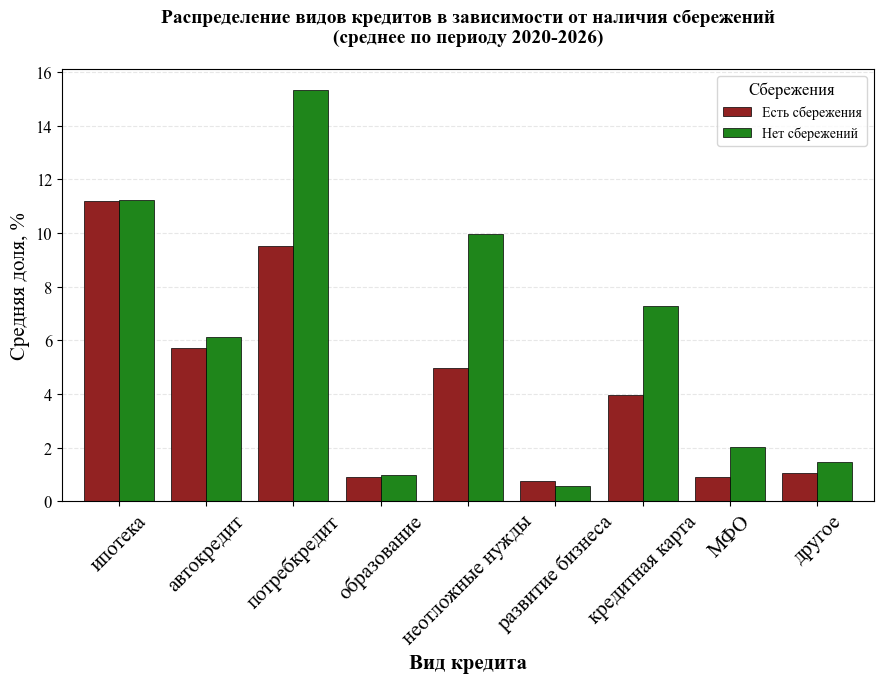

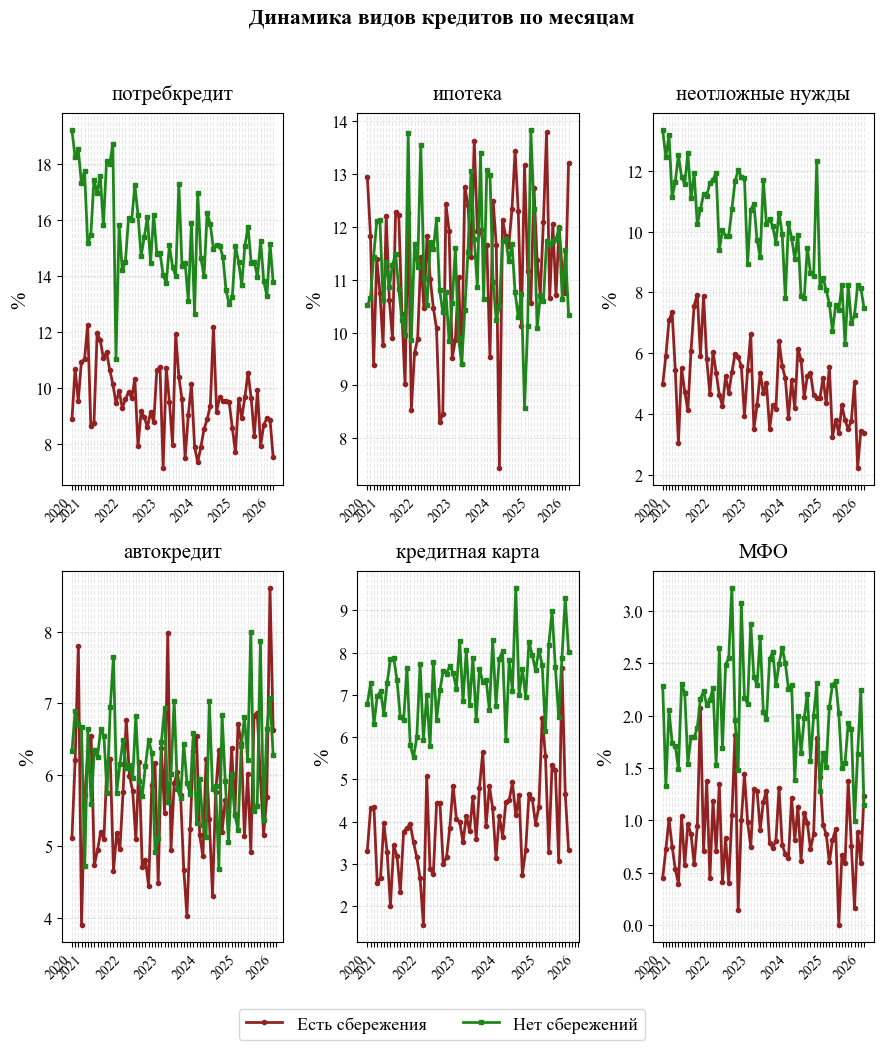

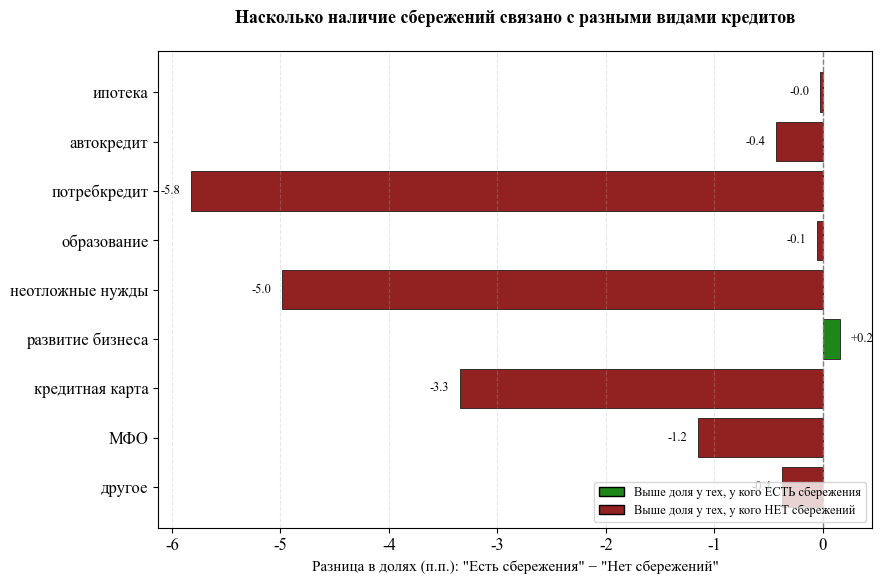

In [3]:

import matplotlib.pyplot as plt

from matplotlib.patches import Patch

# =====================================================
#  УСТАНОВКА ШРИФТА TIMES NEW ROMAN
# =====================================================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Для корректного отображения кириллицы (если нужно)
plt.rcParams['font.sans-serif'] = ['Times New Roman', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # Чтобы корректно отображались минусы

# =====================================================
#  ЦВЕТА
# =====================================================
nonhtm_color = "#922222"  # бордовый - есть сбережения
htm_color = "#1f861b"     # зелёный - нет сбережений

# =====================================================
#  Группированная столбчатая диаграмма
# =====================================================
plt.figure(figsize=(9, 9))

df = sd_df_c.copy(deep=True).set_axis(['ипотека', 'автокредит', 'потребкредит', 'образование',
                                    'неотложные нужды', 'развитие бизнеса', 'кредитная карта', 'МФО', 'другое', 'нет кредита', 'затрудняюсь ответить'], axis = 0)
df_agg = df.T.groupby(level='Сбережения').mean()
credit_cols = [col for col in df_agg.columns if col not in ['нет кредита', 'затрудняюсь ответить']]
df_agg = df_agg[credit_cols].T

ax = df_agg.plot(kind='bar', width=0.8, figsize=(9, 7), 
                 color=[nonhtm_color, htm_color],
                 edgecolor='black', linewidth=0.5)

ax.set_xlabel('Вид кредита', fontsize=15, fontweight='bold')
ax.set_ylabel('Средняя доля, %', fontsize=15)
ax.set_title('Распределение видов кредитов в зависимости от наличия сбережений\n(среднее по периоду 2020-2026)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(['Есть сбережения', 'Нет сбережений'], title='Сбережения', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('data/pie_plots/grouped_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
#  Динамика по месяцам (линейные графики)
# =====================================================
df = df.T.copy()
top_credits = df[credit_cols].mean().nlargest(6).index.tolist()

months = df.xs('есть', level='Сбережения').index.tolist()

def create_year_labels(months):
    labels = []
    prev_year = None
    for month in months:
        year = month.split('-')[0]
        if year != prev_year:
            labels.append(year)
            prev_year = year
        else:
            labels.append('')
    return labels

xsticks_labels = create_year_labels(months)

fig, axes = plt.subplots(2, 3, figsize=(9, 10))
axes = axes.flatten()

handles, labels = None, None

for idx, credit in enumerate(top_credits):
    ax = axes[idx]
    
    line_yes = df.xs('есть', level='Сбережения')[credit]
    line_no = df.xs('нет', level='Сбережения')[credit]
    
    line1, = ax.plot(line_yes.index, line_yes.values, marker='o', markersize=3, 
            label='Есть сбережения', linewidth=2, color=nonhtm_color)
    line2, = ax.plot(line_no.index, line_no.values, marker='s', markersize=3, 
            label='Нет сбережений', linewidth=2, color=htm_color)
    
    if idx == 0:
        handles = [line1, line2]
        labels = ['Есть сбережения', 'Нет сбережений']
    
    ax.set_title(credit, fontsize=15, pad=10)
    ax.set_ylabel('%', fontsize=15)
    ax.set_xticks(range(len(months)))
    ax.set_xticklabels(xsticks_labels, rotation=45, ha='right', fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

# Общая легенда внизу
fig.legend(handles=handles, labels=labels, 
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=2, fontsize=13, frameon=True)

plt.suptitle('Динамика видов кредитов по месяцам', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('data/pie_plots/dynamics_top6.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
#  Сравнение разницы "есть - нет сбережений"
# =====================================================
diff = df_agg['есть'] - df_agg['нет']

plt.figure(figsize=(9, 6))
colors = [htm_color if x > 0 else nonhtm_color for x in diff.values]
bars = plt.barh(diff.index, diff.values, color=colors, edgecolor='black', linewidth=0.5)

plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Разница в долях (п.п.): "Есть сбережения" − "Нет сбережений"', fontsize=11)
plt.title('Насколько наличие сбережений связано с разными видами кредитов', 
          fontsize=13, fontweight='bold', pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    offset = 0.1 if width > 0 else -0.1
    ha = 'left' if width > 0 else 'right'
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, 
             f'{width:+.1f}', ha=ha, va='center', fontsize=9)

# Легенда для цветов
legend_elements = [
    Patch(facecolor=htm_color, edgecolor='black', label='Выше доля у тех, у кого ЕСТЬ сбережения'),
    Patch(facecolor=nonhtm_color, edgecolor='black', label='Выше доля у тех, у кого НЕТ сбережений')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('data/pie_plots/diff_bars.png', dpi=300, bbox_inches='tight')
plt.show()

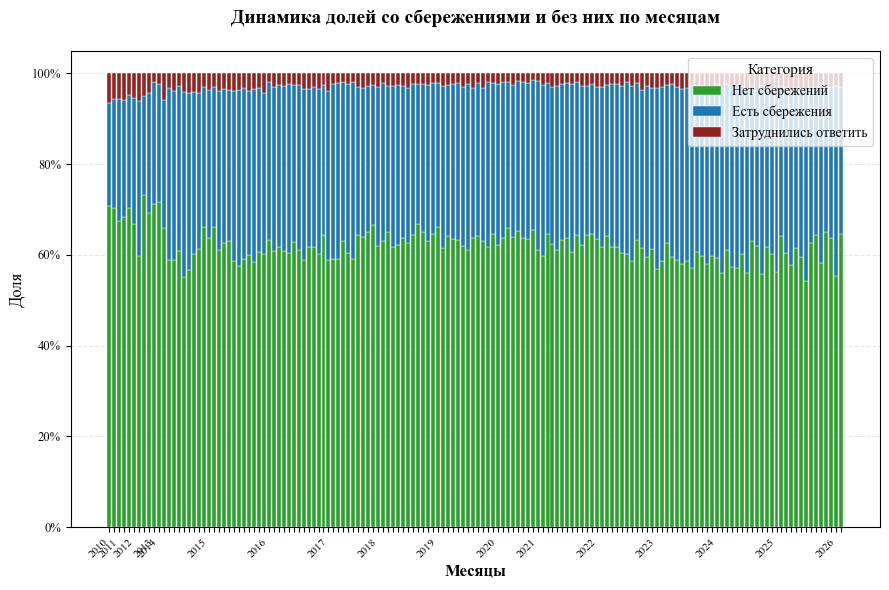

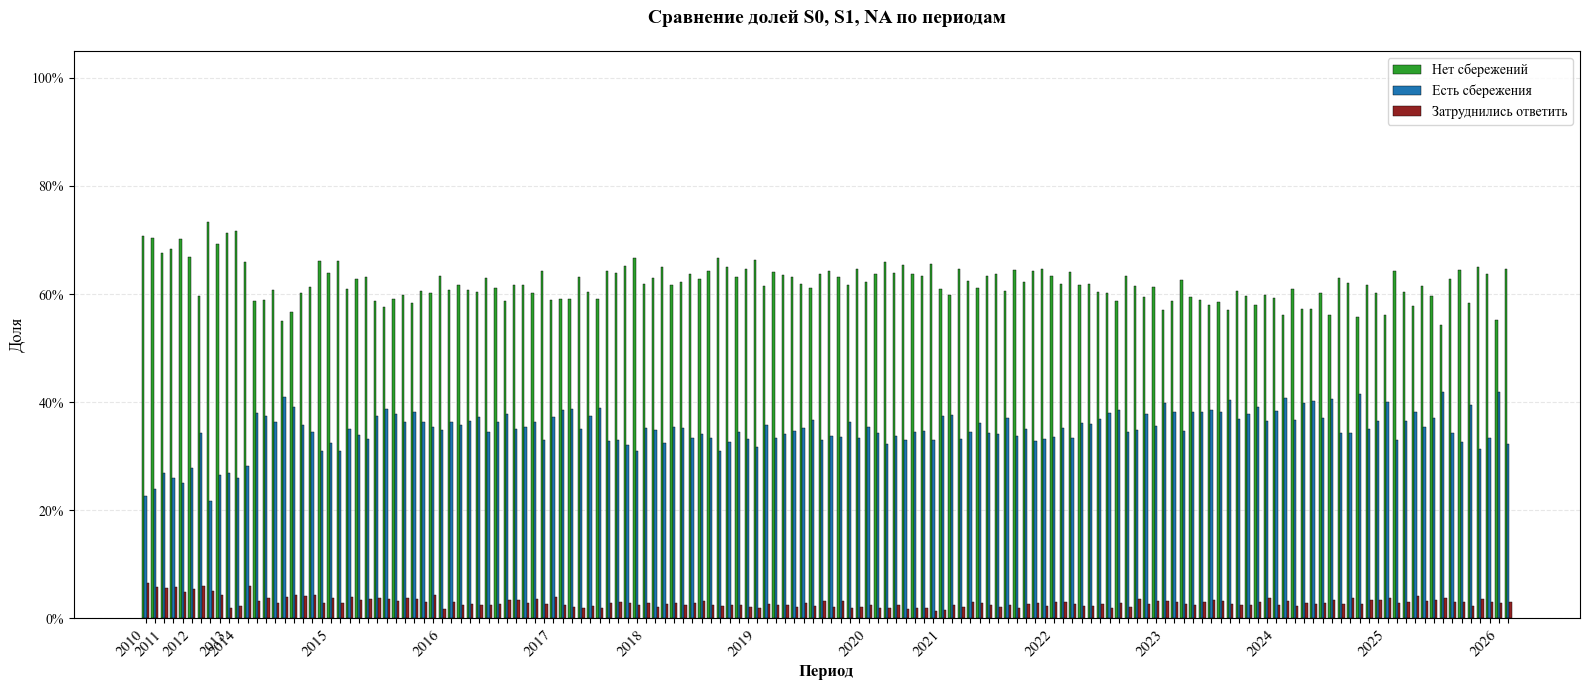

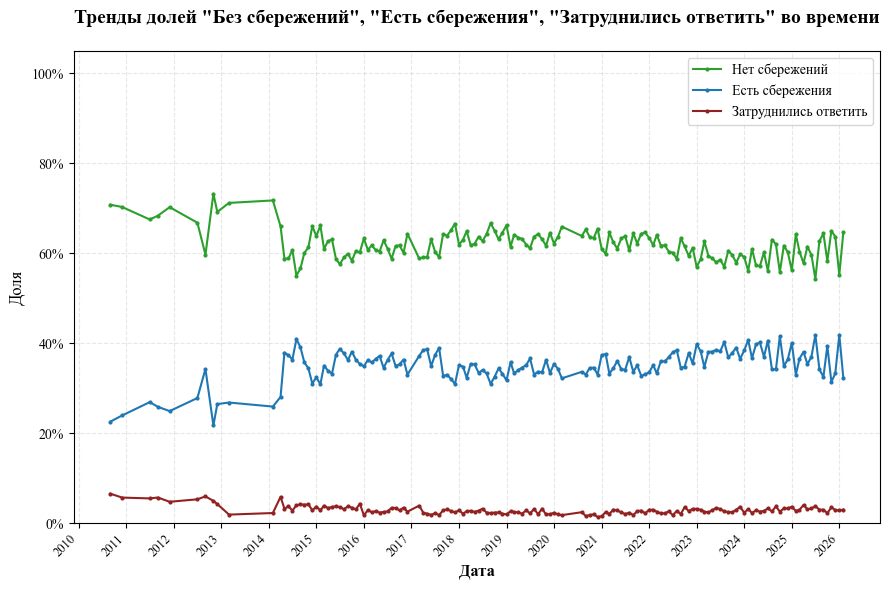

📊 Статистика по долям:
                       count      mean       std       min       25%  \
нет сбережений         148.0  0.620551  0.034345  0.543112  0.597607   
есть сбережения        148.0  0.349540  0.036410  0.217500  0.333125   
затруднились ответить  148.0  0.029909  0.009260  0.014378  0.024000   

                            50%       75%       max  
нет сбережений         0.617719  0.641070  0.732500  
есть сбережения        0.351338  0.373625  0.418812  
затруднились ответить  0.028500  0.033238  0.066000  

🔍 Последние 5 периодов:
            нет сбережений  есть сбережения  затруднились ответить
2025-10-01        0.582712         0.394436               0.022851
2025-11-01        0.650124         0.314144               0.035732
2025-12-01        0.637129         0.333168               0.029703
2026-01-01        0.552475         0.418812               0.028713
2026-02-01        0.646855         0.322437               0.030708

✅ Проверка: сумма по строкам (должна быть ~1

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.dates import DateFormatter, MonthLocator, YearLocator

# =====================================================
# 🔤 ШРИФТЫ И НАСТРОЙКИ
# =====================================================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

# =====================================================
# 📥 ЗАГРУЗКА ДАННЫХ
# =====================================================
df = pd.read_excel('data/sdf_excel.xlsx', index_col=0, parse_dates=True).set_axis(['нет сбережений', 'есть сбережения', 'затруднились ответить'], axis = 1)
df.index = pd.to_datetime(df.index)
df = df.sort_index()  # Сортируем по времени

# Категории и цвета
categories = ['нет сбережений', 'есть сбережения', 'затруднились ответить']
colors = {
    'нет сбережений': '#2ca02c',    # синий
    'есть сбережения': '#1f77b4',    # зелёный
    'затруднились ответить': '#922222'     # бордовый
}
labels = {
    'нет сбережений': 'Нет сбережений',    # синий
    'есть сбережения': 'Есть сбережения',    # зелёный
    'затруднились ответить': 'Затруднились ответить'
}

# =====================================================
# 📊 ГРАФИК 1: Стэкированные бары (доли в сумме = 1)
# =====================================================
fig, ax = plt.subplots(figsize=(9, 6))

# Для стэкинга: используем bar с параметром bottom
x = np.arange(len(df))
bottom = np.zeros(len(df))

for cat in categories:
    ax.bar(x, df[cat], bottom=bottom, label=labels[cat],
           color=colors[cat], edgecolor='white', linewidth=0.3)
    bottom += df[cat]

# Подписи осей и заголовок
ax.set_xlabel('Месяцы', fontsize=12, fontweight='bold')
ax.set_ylabel('Доля', fontsize=12)
ax.set_title('Динамика долей со сбережениями и без них по месяцам', 
             fontsize=14, fontweight='bold', pad=20)

# 🔹 Ось X: показываем годы при смене
years = df.index.year
xtick_labels = []
prev_year = None
for i, y in enumerate(years):
    if y != prev_year:
        xtick_labels.append(str(y))
        prev_year = y
    else:
        xtick_labels.append('')

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)

# 🔹 Ось Y: проценты
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([f'{int(p*100)}%' for p in np.arange(0, 1.1, 0.2)], fontsize=9)

# Сетка, легенда, лимиты
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(title='Категория', fontsize=10, title_fontsize=11, loc='upper right')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('data/pie_plots/sdf_stacked_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 📊 ГРАФИК 2: Группированные бары (если хотите сравнение)
# =====================================================
fig, ax = plt.subplots(figsize=(16, 7))

width = 0.25
x = np.arange(len(df))

for idx, cat in enumerate(categories):
    ax.bar(x + (idx - 1) * width, df[cat], width, label=labels[cat],
           color=colors[cat], edgecolor='black', linewidth=0.3)

ax.set_xlabel('Период', fontsize=12, fontweight='bold')
ax.set_ylabel('Доля', fontsize=12)
ax.set_title('Сравнение долей S0, S1, NA по периодам', 
             fontsize=14, fontweight='bold', pad=20)

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=11)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([f'{int(p*100)}%' for p in np.arange(0, 1.1, 0.2)])
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('data/pie_plots/sdf_grouped_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 📈 ГРАФИК 3: Линейный график (для трендов)
# =====================================================
fig, ax = plt.subplots(figsize=(9, 6))

for cat in categories:
    ax.plot(df.index, df[cat], marker='o', markersize=2,
            label=labels[cat], color=colors[cat], linewidth=1.5)

ax.set_xlabel('Дата', fontsize=12, fontweight='bold')
ax.set_ylabel('Доля', fontsize=12)
ax.set_title('Тренды долей "Без сбережений", "Есть сбережения", "Затруднились ответить" во времени', 
             fontsize=14, fontweight='bold', pad=20)

# Форматирование дат на оси X
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([f'{int(p*100)}%' for p in np.arange(0, 1.1, 0.2)])
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('data/pie_plots/sdf_lines.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 🎁 БОНУС: Статистика по категориям
# =====================================================
print("📊 Статистика по долям:")
print(df[categories].describe().T)

print("\n🔍 Последние 5 периодов:")
print(df[categories].tail())

print("\n✅ Проверка: сумма по строкам (должна быть ~1.0):")
print(df[categories].sum(axis=1).tail())